# Pooling

# With NumPy (maxpooling)

In [13]:
# 1) 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(X_train, _), _ = mnist.load_data()
image = X_train[0]   # shape: (28, 28)

# Normalize (optional but good practice)
image = image / 255.0

# Max Pooling function (2x2)
def max_pooling(image, pool_size=2):
    h, w = image.shape
    
    # Output size
    new_h = h // pool_size
    new_w = w // pool_size
    
    pooled = np.zeros((new_h, new_w))
    
    for i in range(new_h):
        for j in range(new_w):
            # Extract 2x2 patch
            patch = image[i*pool_size:(i+1)*pool_size,
                          j*pool_size:(j+1)*pool_size]
            
            # Take max
            pooled[i, j] = np.max(patch)
    
    return pooled

# Apply pooling
pooled_image = max_pooling(image, 2)

In [14]:
# 2)

# Prevent wrapping
np.set_printoptions(precision=2, suppress=True, linewidth=200)

print("Original Image:\n", image)
print("\nPooled Image:\n", pooled_image)

Original Image:
 [[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.07 0.07 0.07 0.49 0.53 0.69 0.1  0.65 1.   0.97 0.5  0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.12 0.14 0.37 0.6  0.67 0.99 0.99 0.99 0.99 0.99 0.88 0.67 0.99 0.95 0.76 0.25 0. 

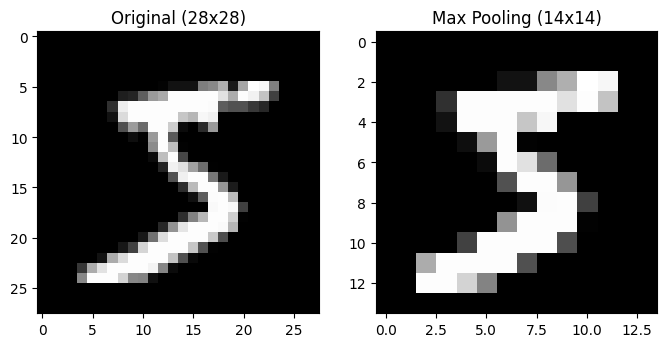

In [9]:
# 3) Plot results
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original (28x28)")
plt.imshow(image, cmap='gray')

plt.subplot(1,2,2)
plt.title("Max Pooling (14x14)")
plt.imshow(pooled_image, cmap='gray')

plt.show()


# With Tensorflow (maxpooling)

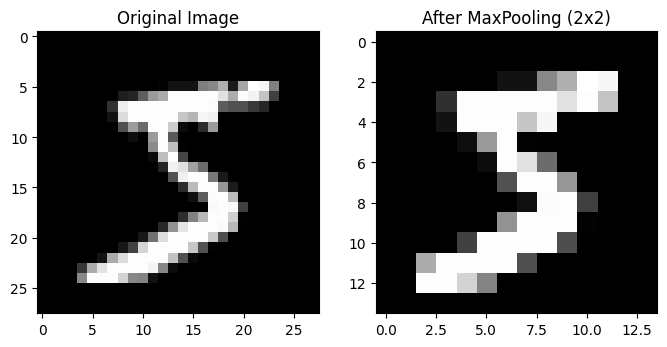

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# Create a sample image (or use MNIST)
from tensorflow.keras.datasets import mnist
(X_train, _), _ = mnist.load_data()

image = X_train[0]

# Normalize
image = image / 255.0

# Reshape for CNN (batch, height, width, channel)
image = image.reshape(1, 28, 28, 1)

# Apply MaxPooling
pool = layers.MaxPooling2D(pool_size=(2,2))
pooled_image = pool(image)

# Convert back for visualization
original = image.reshape(28, 28)
pooled = pooled_image.numpy().reshape(14, 14)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(original, cmap='gray')

plt.subplot(1,2,2)
plt.title("After MaxPooling (2x2)")
plt.imshow(pooled, cmap='gray')

plt.show()


# Observation:
Key Points
1. Size Reduction   28×28 → 14×14

2. Computation Reduction: Fewer pixels → faster training

3. Feature Retention: Important structures still visible

# With Tensorflow (average pooling)

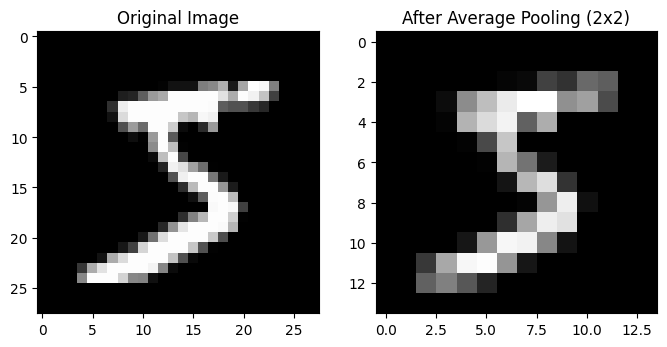

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# Create a sample image (or use MNIST)
from tensorflow.keras.datasets import mnist
(X_train, _), _ = mnist.load_data()

image = X_train[0]

# Normalize
image = image / 255.0

# Reshape for CNN (batch, height, width, channel)
image = image.reshape(1, 28, 28, 1)

# Apply MaxPooling
pool = layers.AveragePooling2D(pool_size=(2,2))
pooled_image = pool(image)

# Convert back for visualization
original = image.reshape(28, 28)
pooled = pooled_image.numpy().reshape(14, 14)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(original, cmap='gray')

plt.subplot(1,2,2)
plt.title("After Average Pooling (2x2)")
plt.imshow(pooled, cmap='gray')

plt.show()
